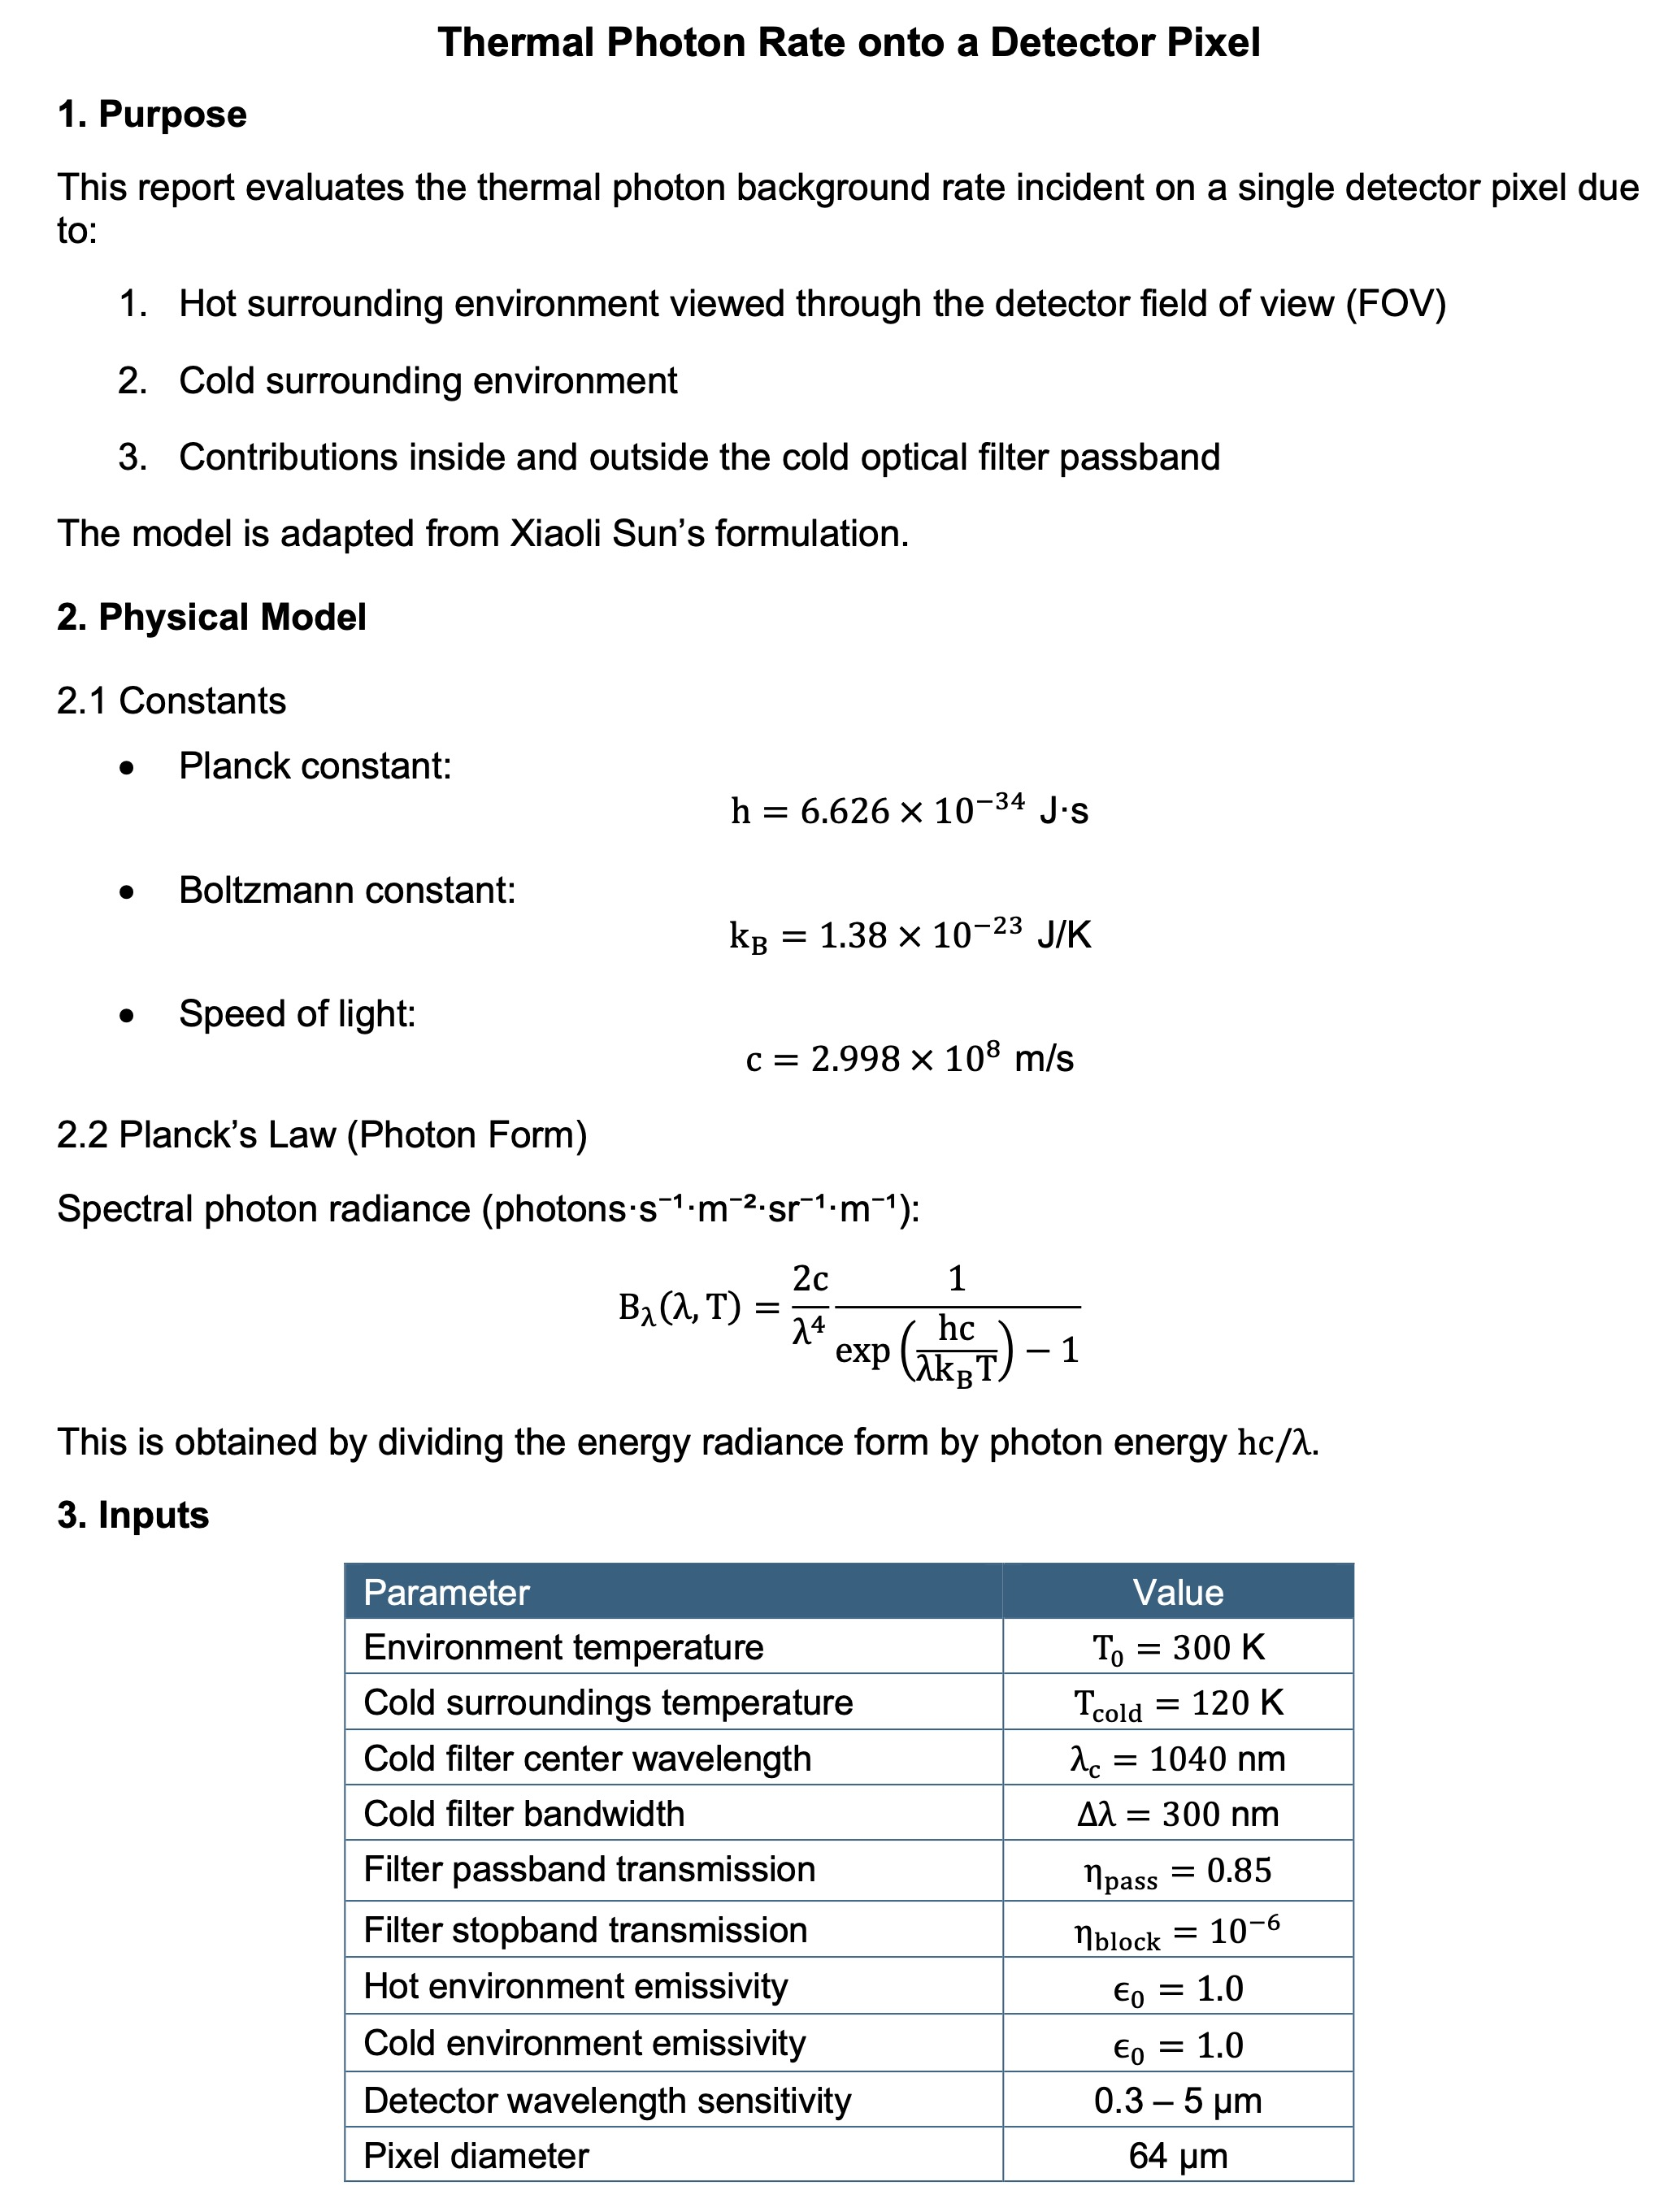

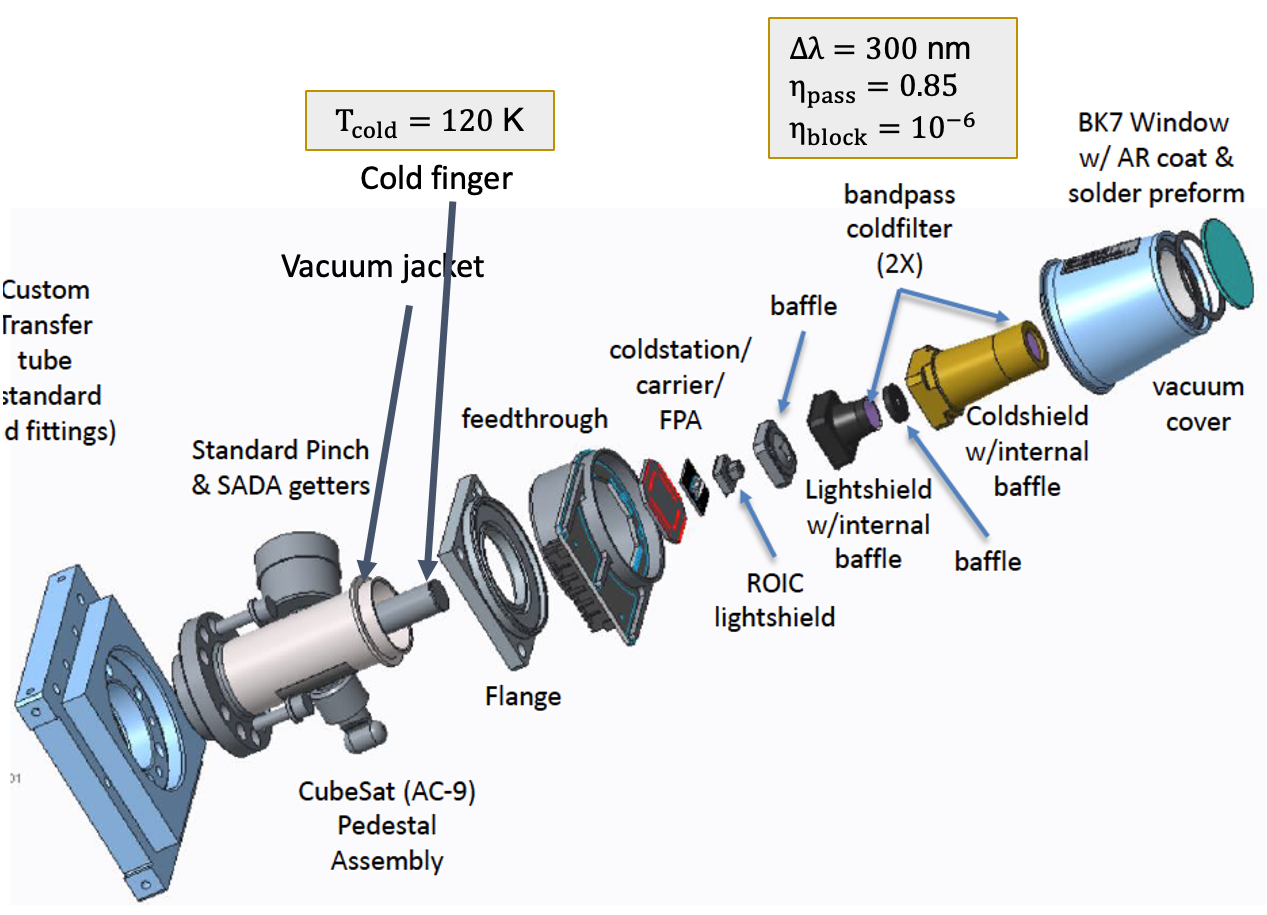

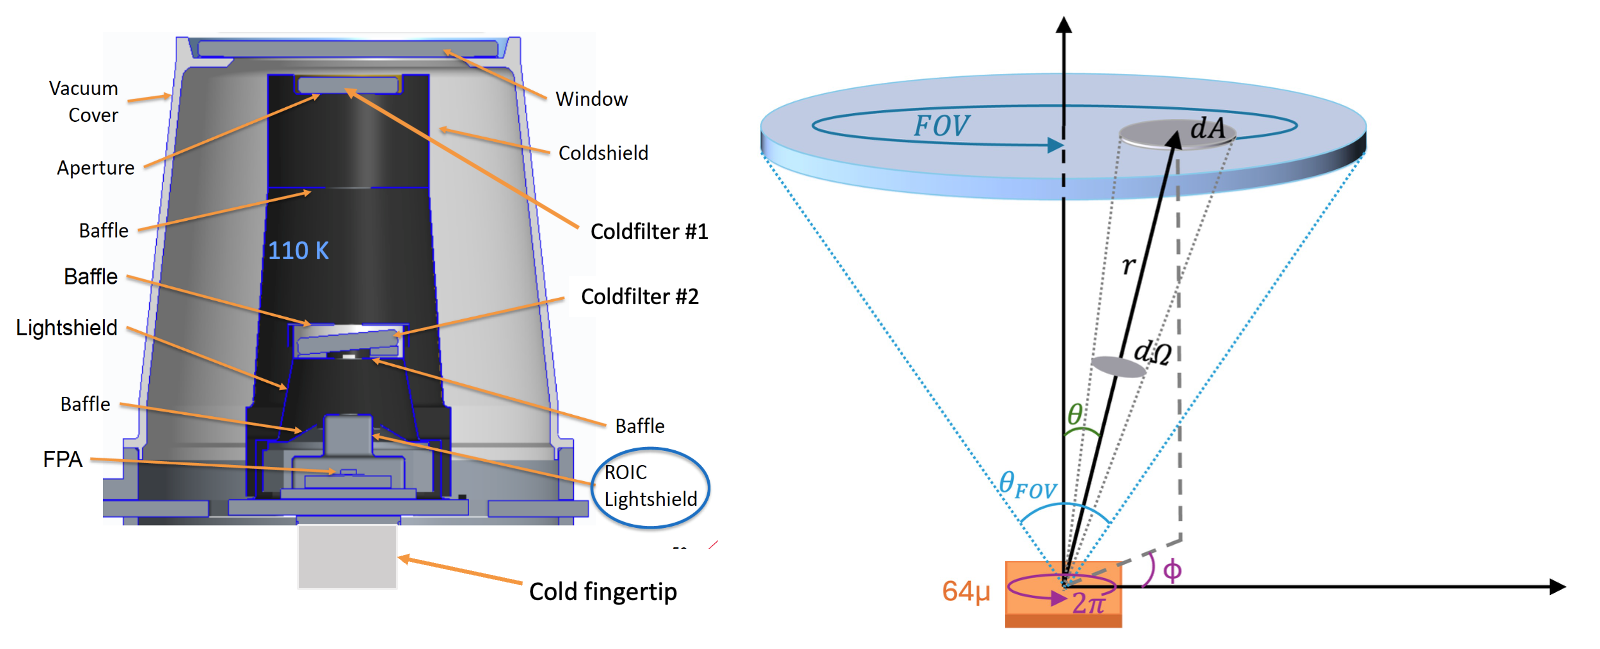

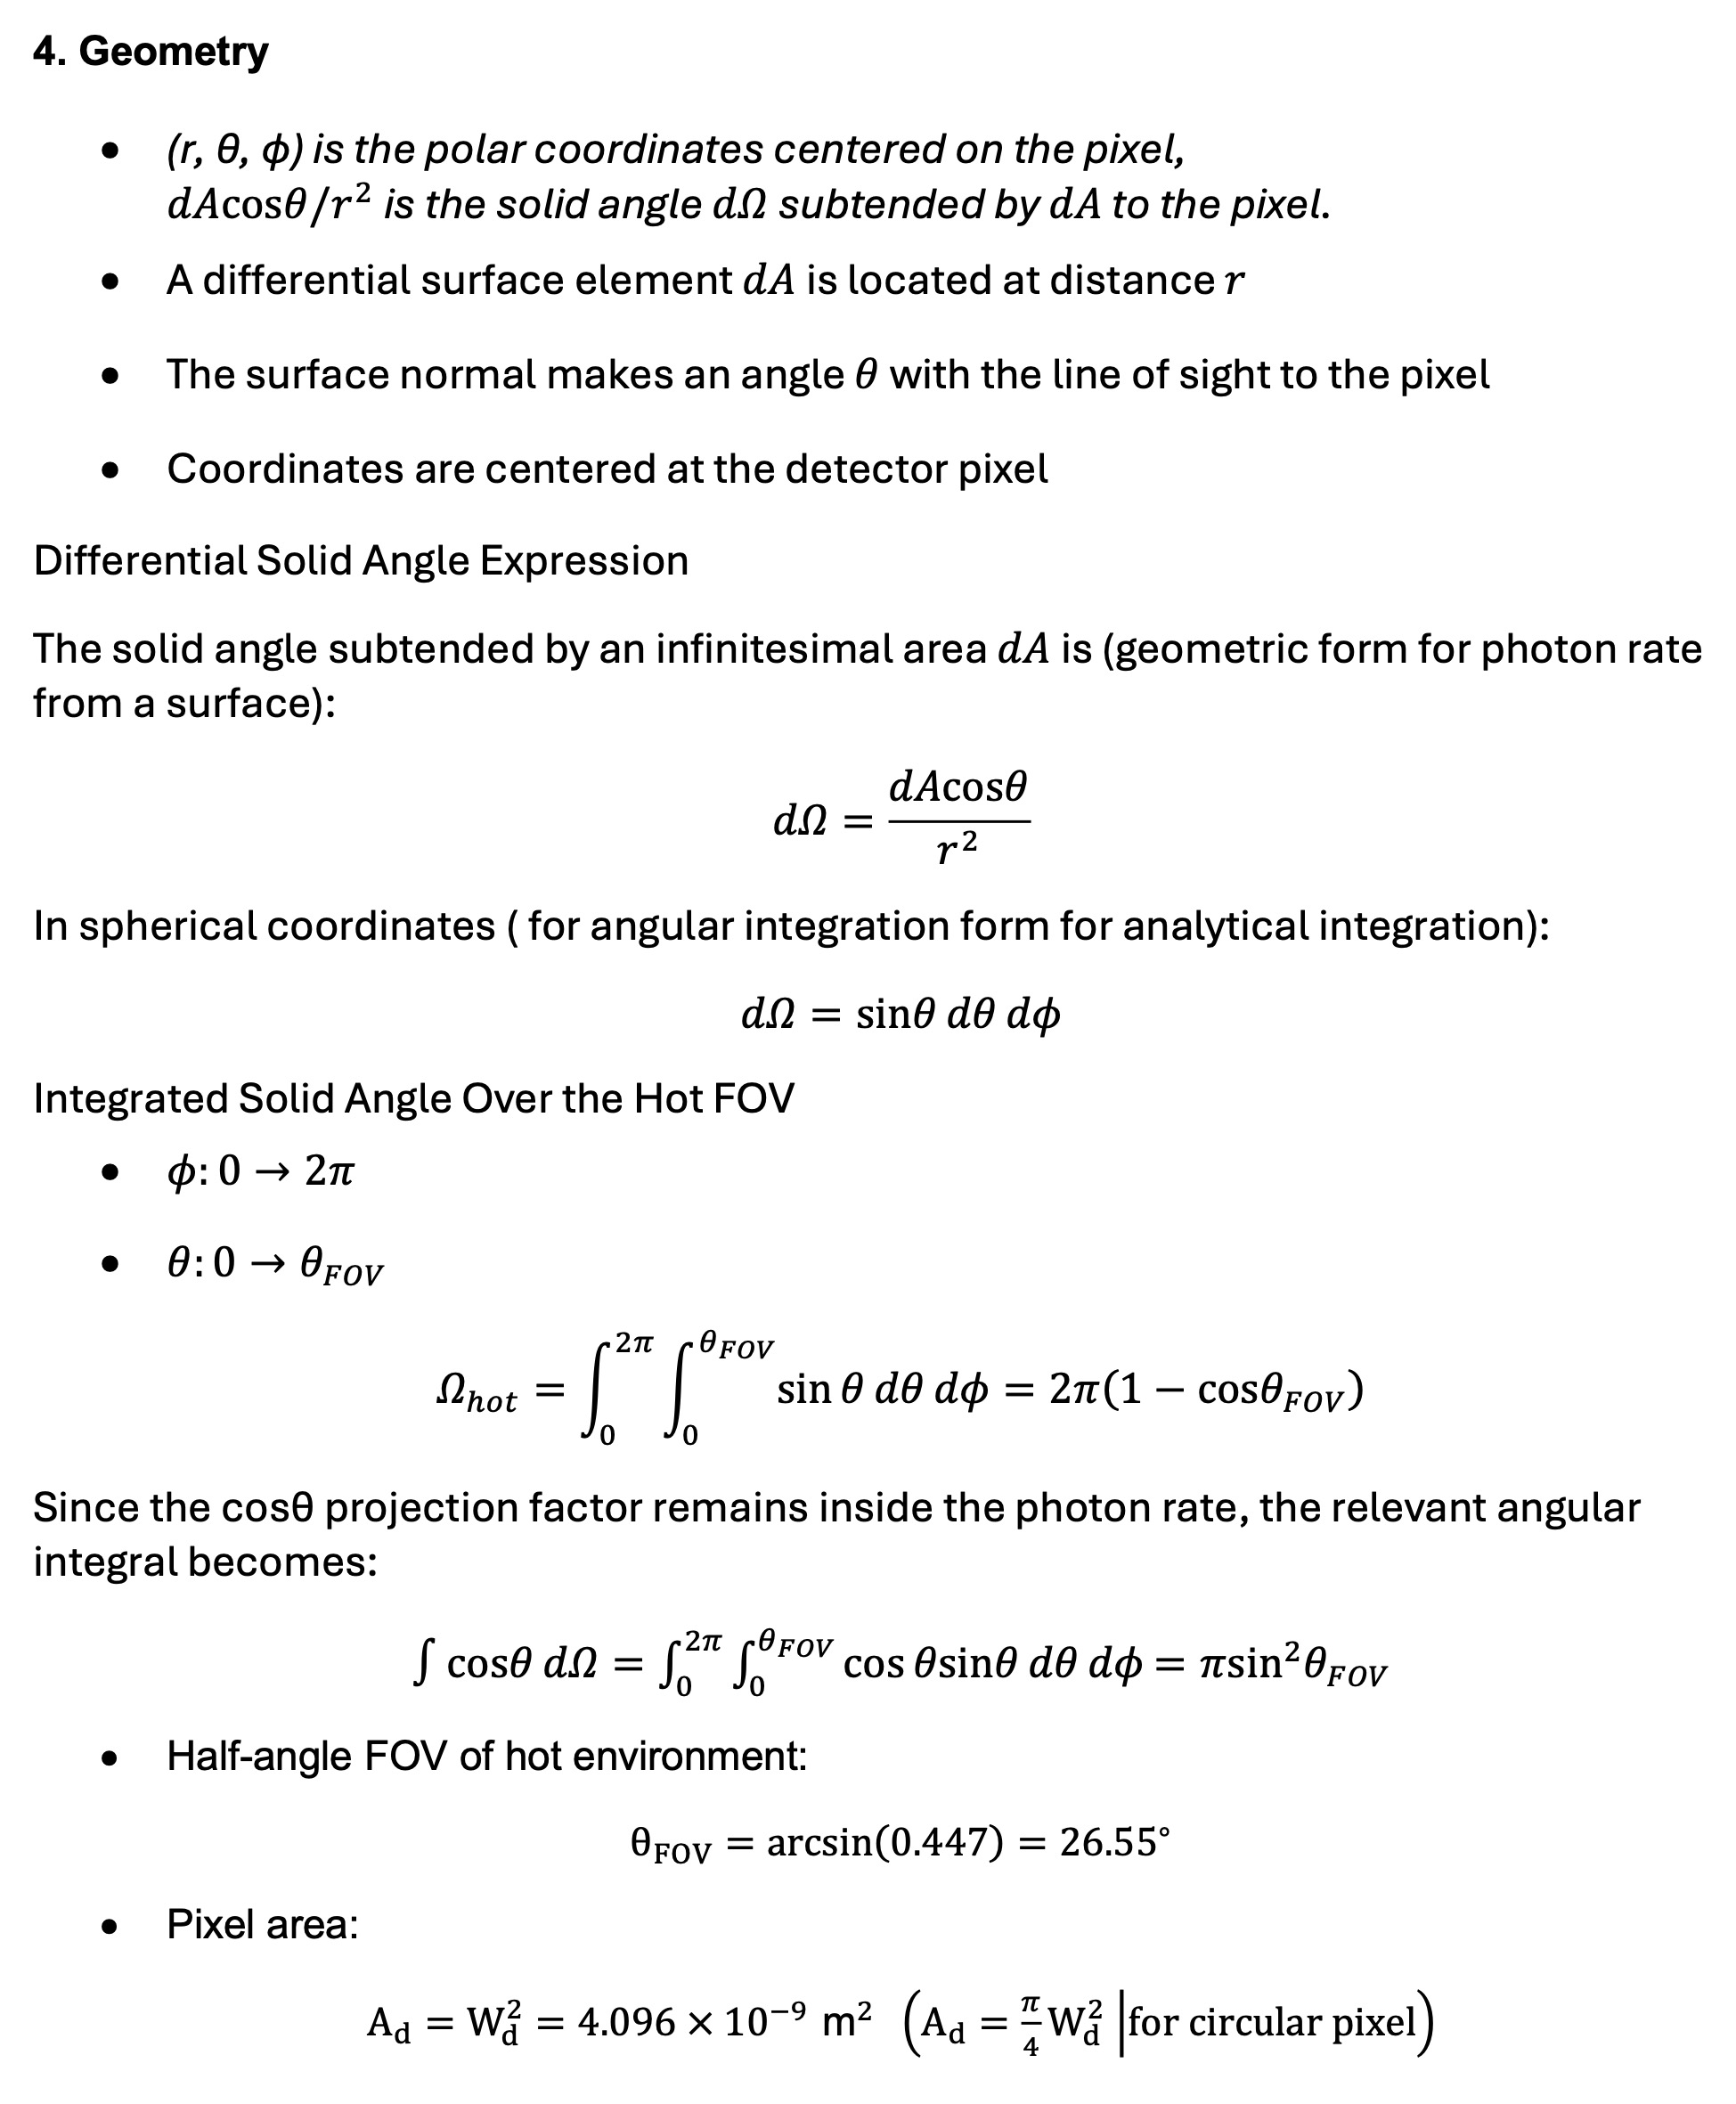

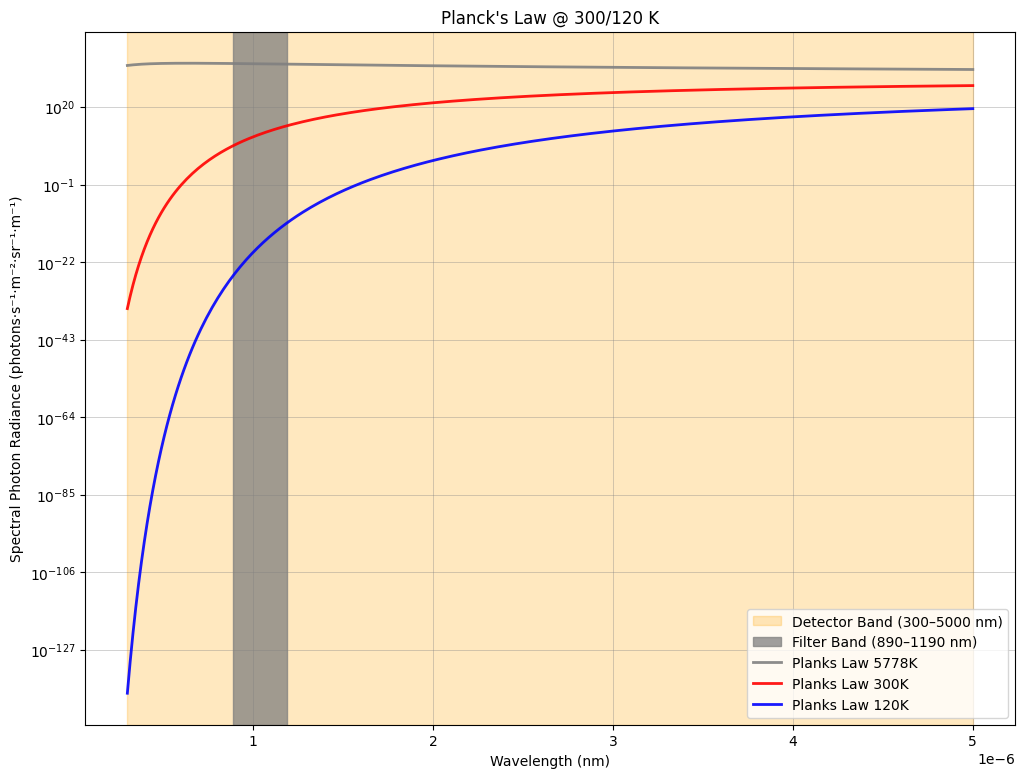

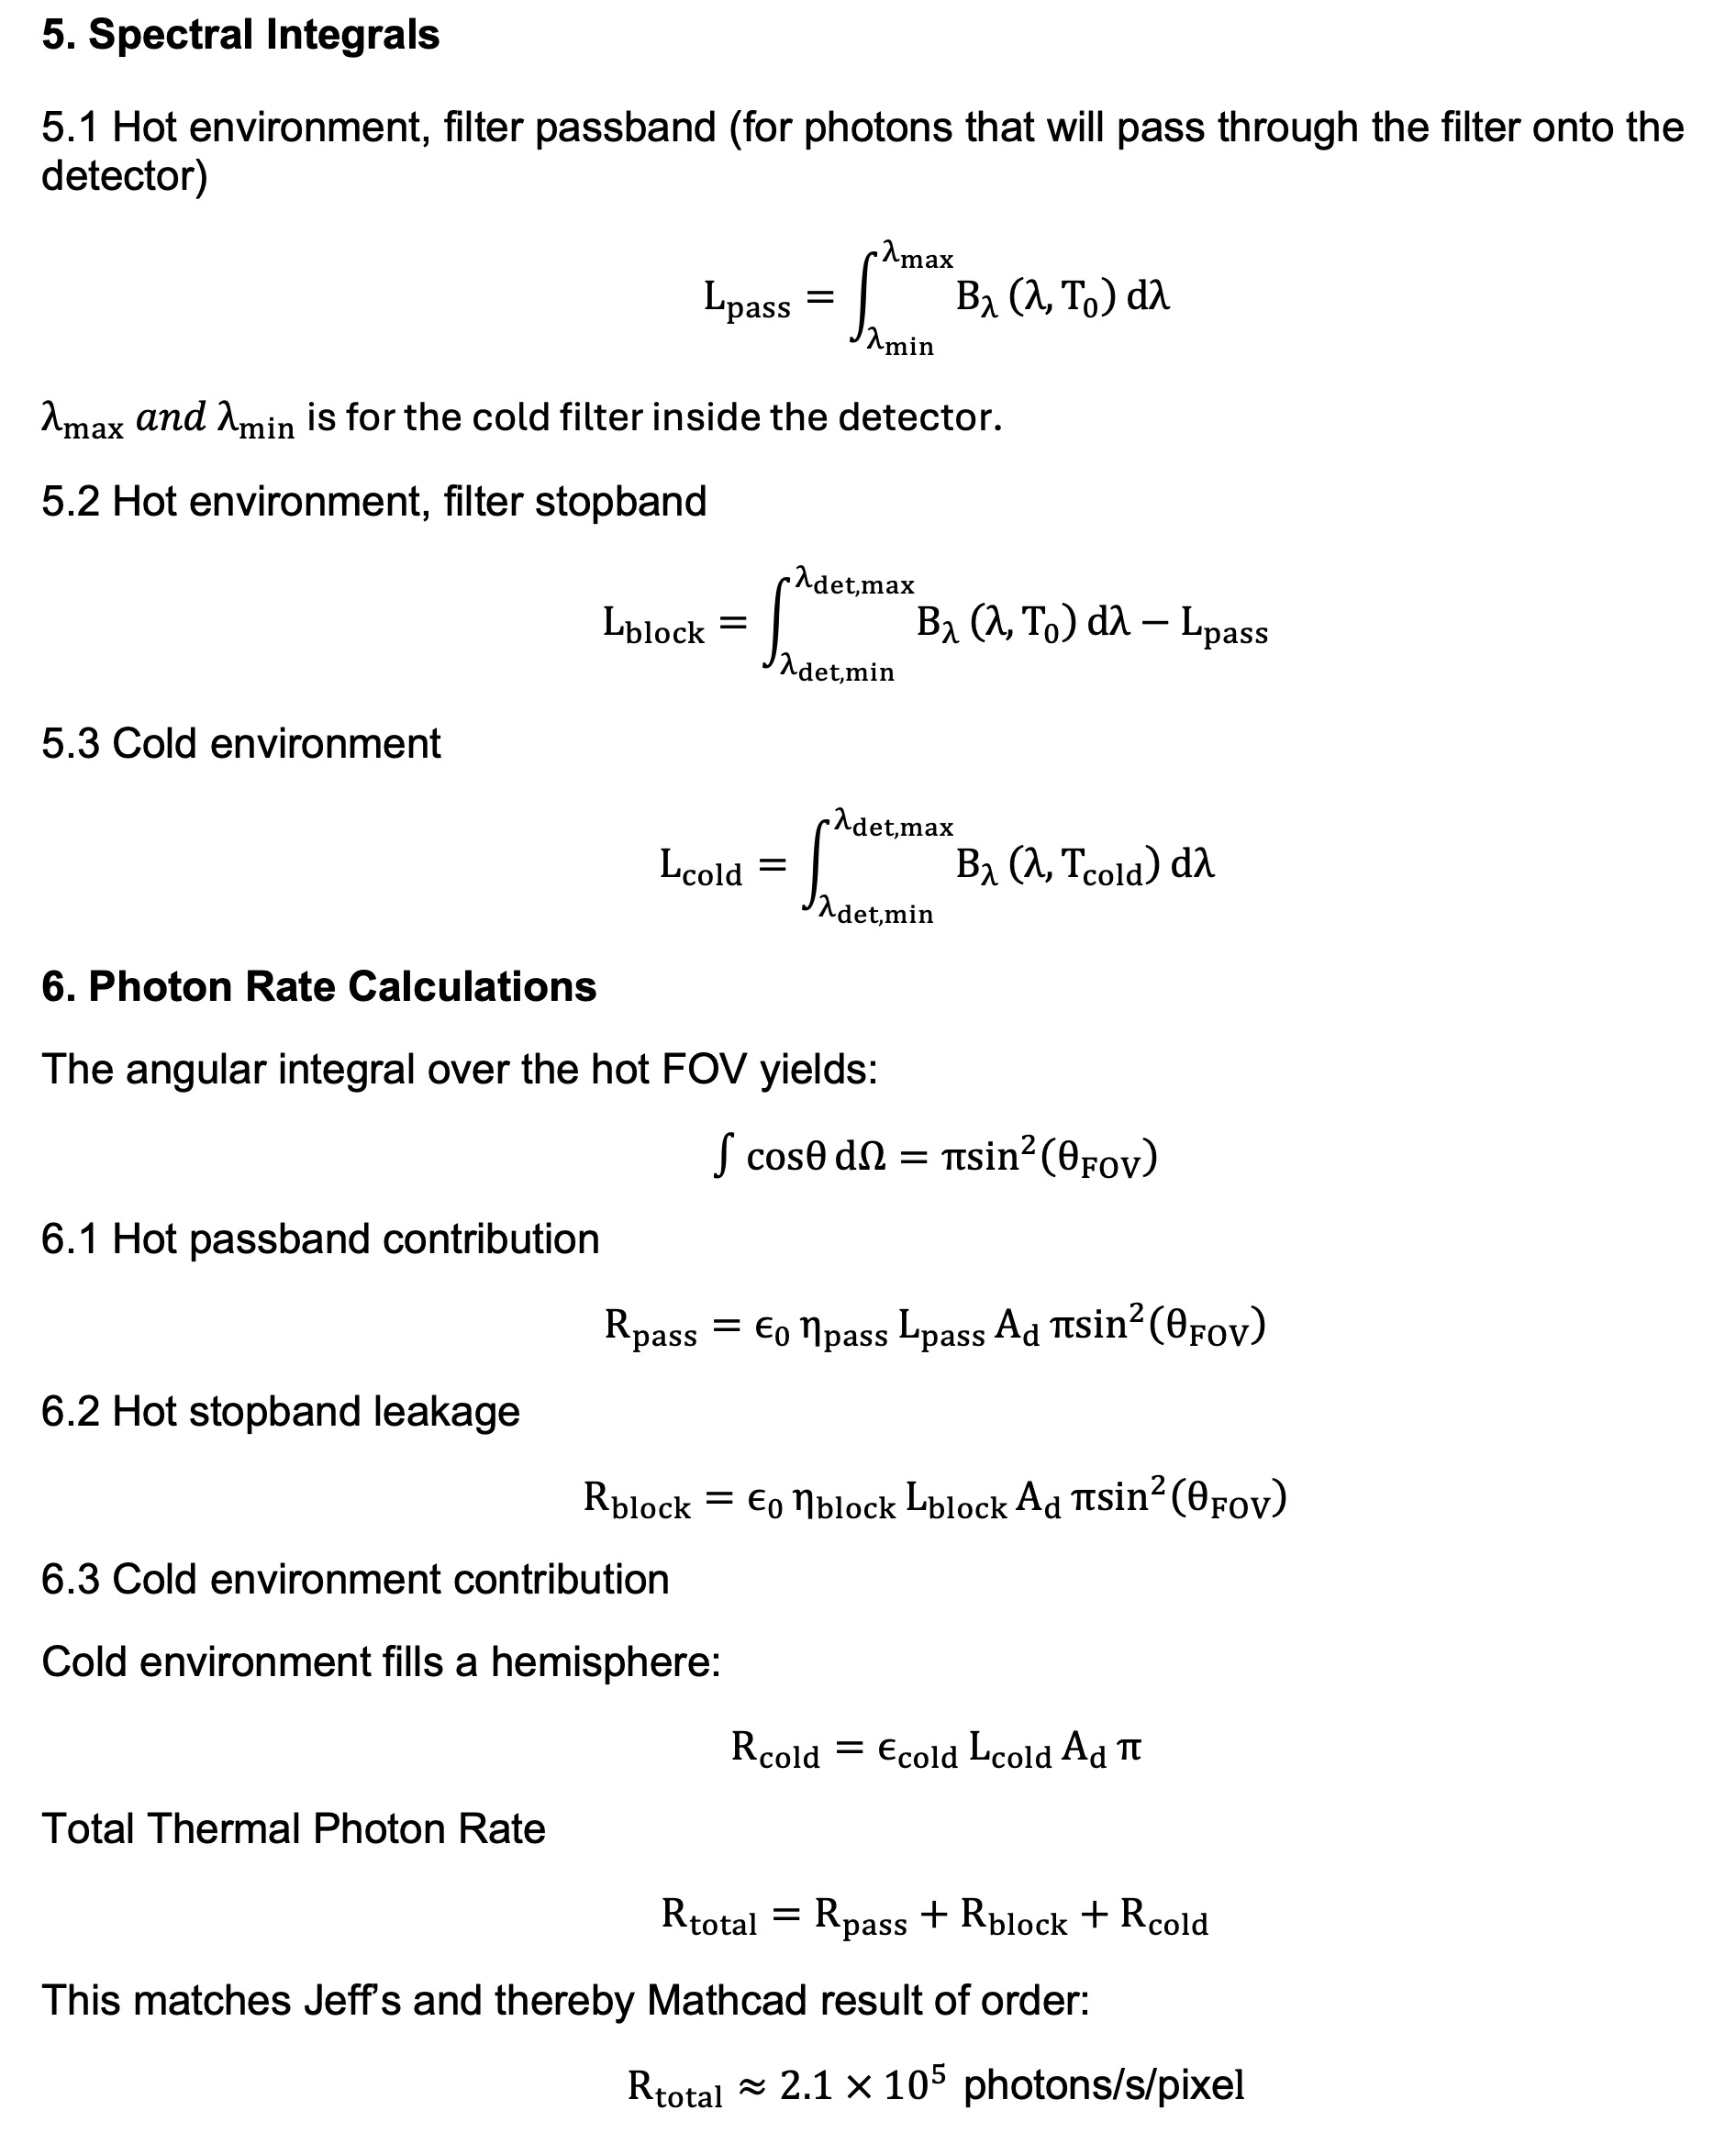

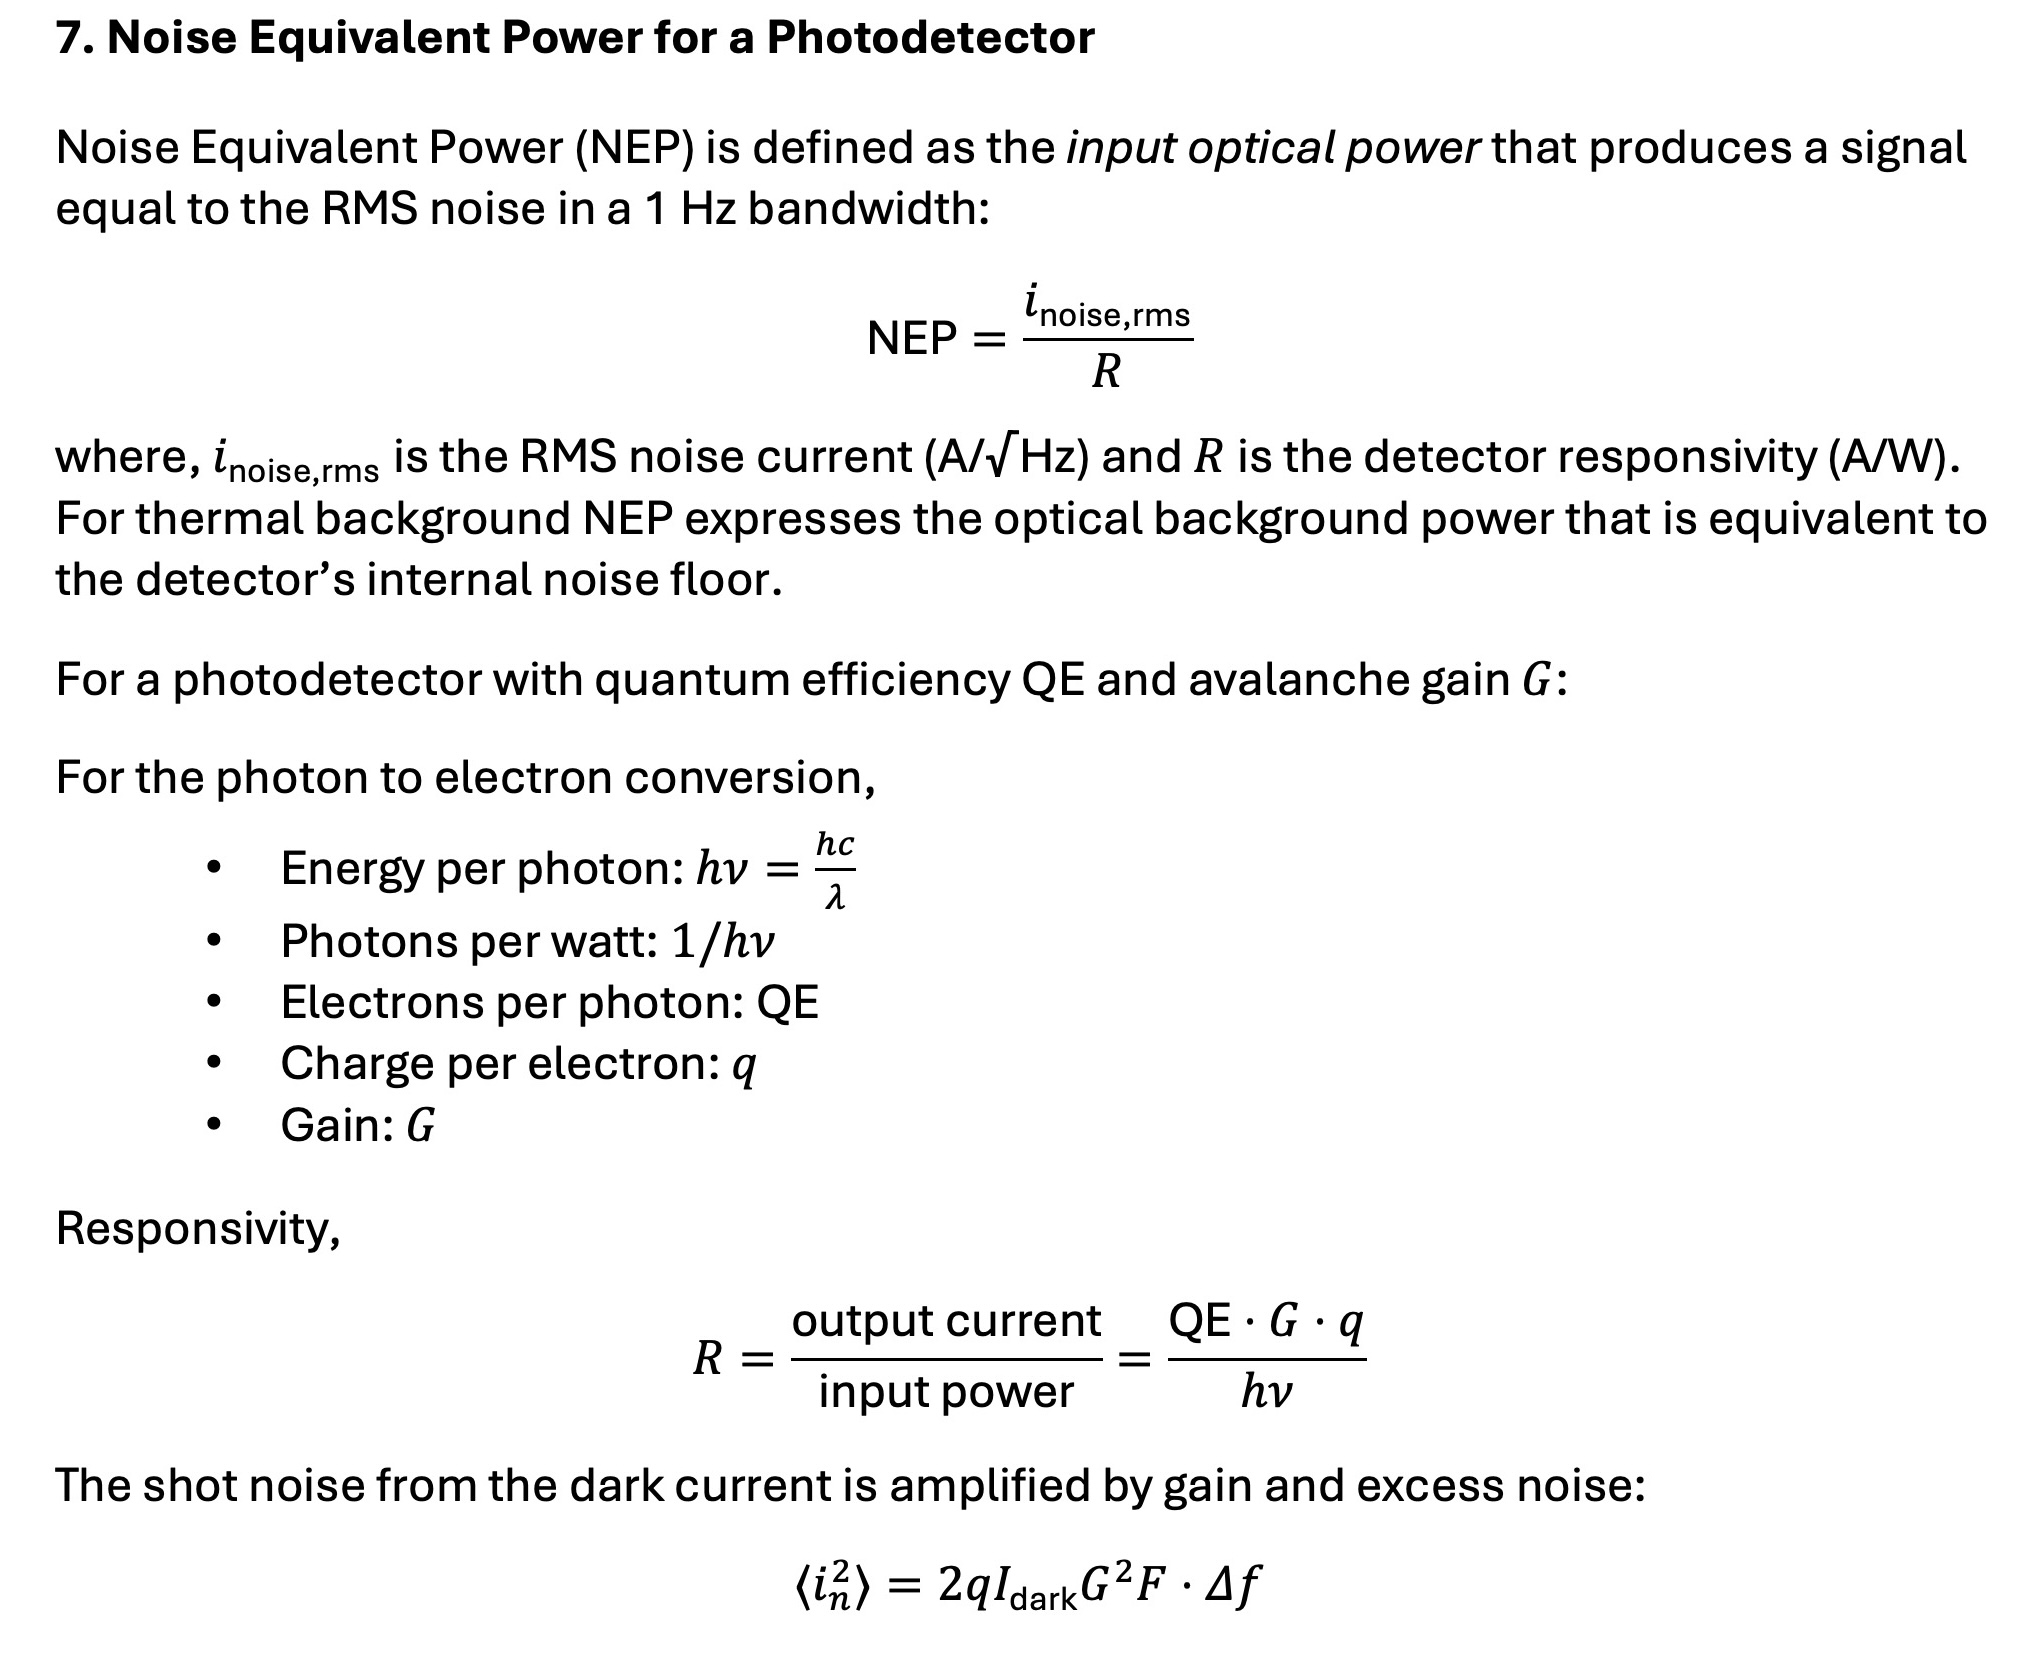

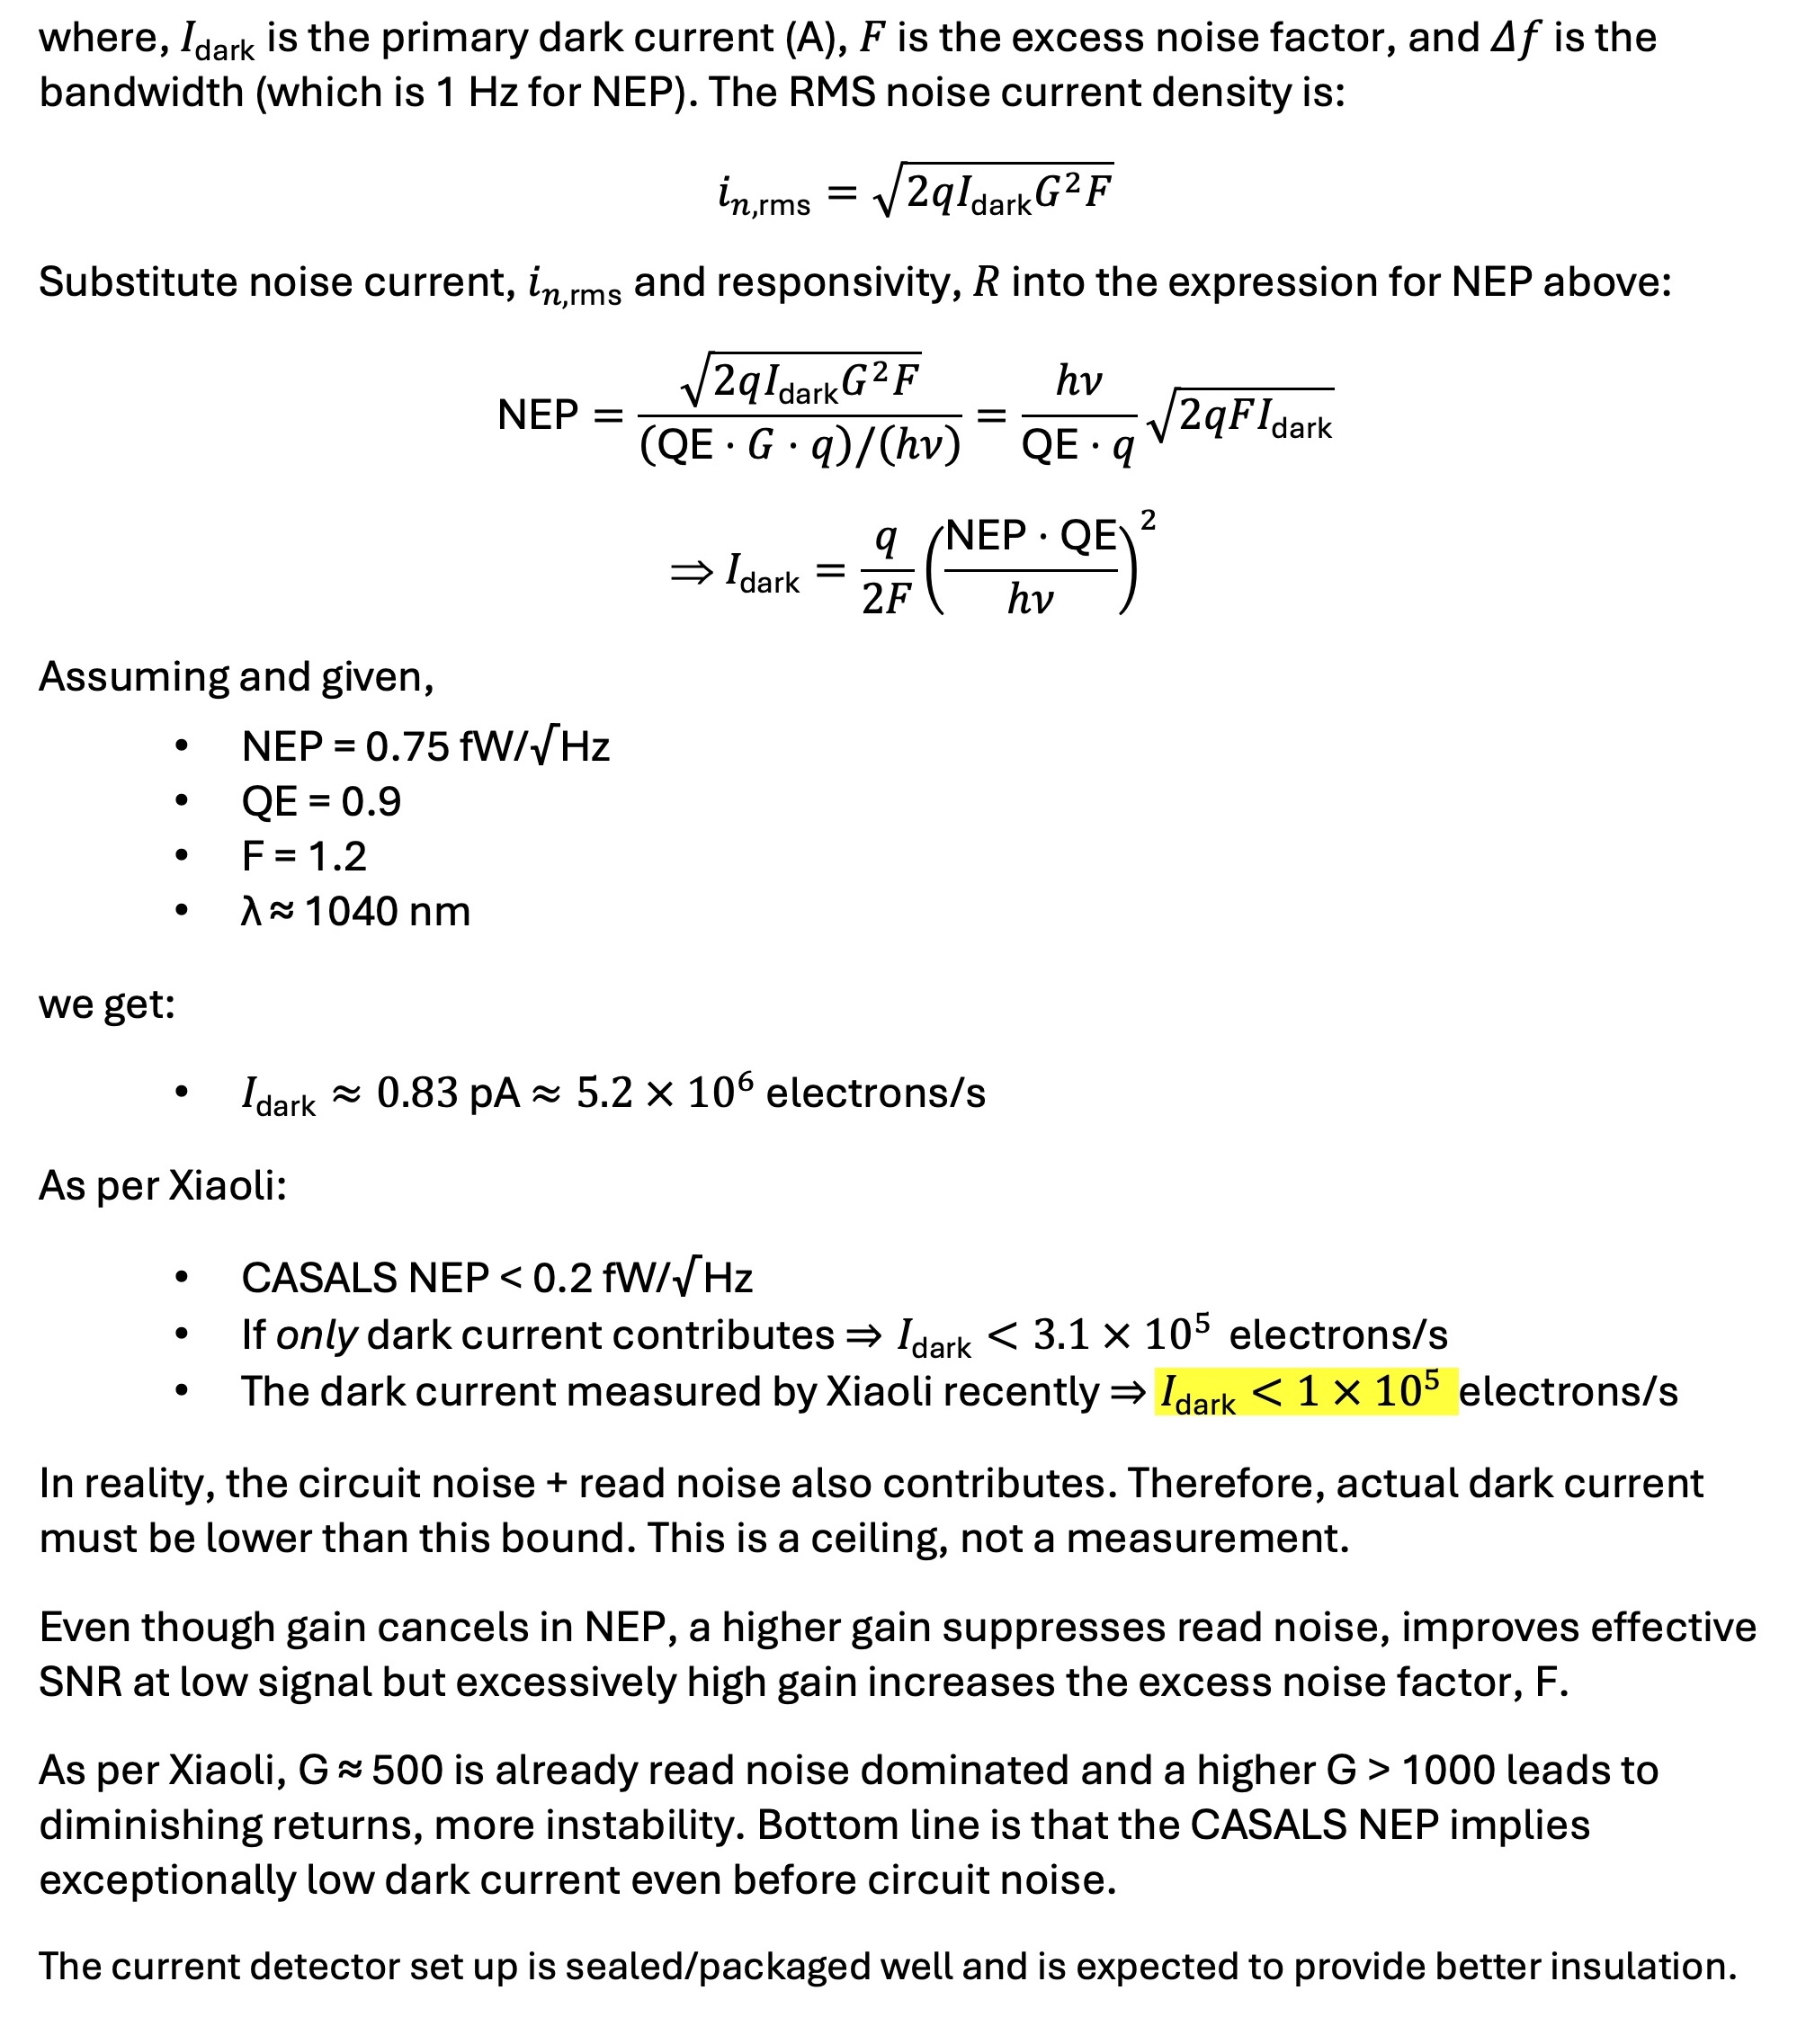

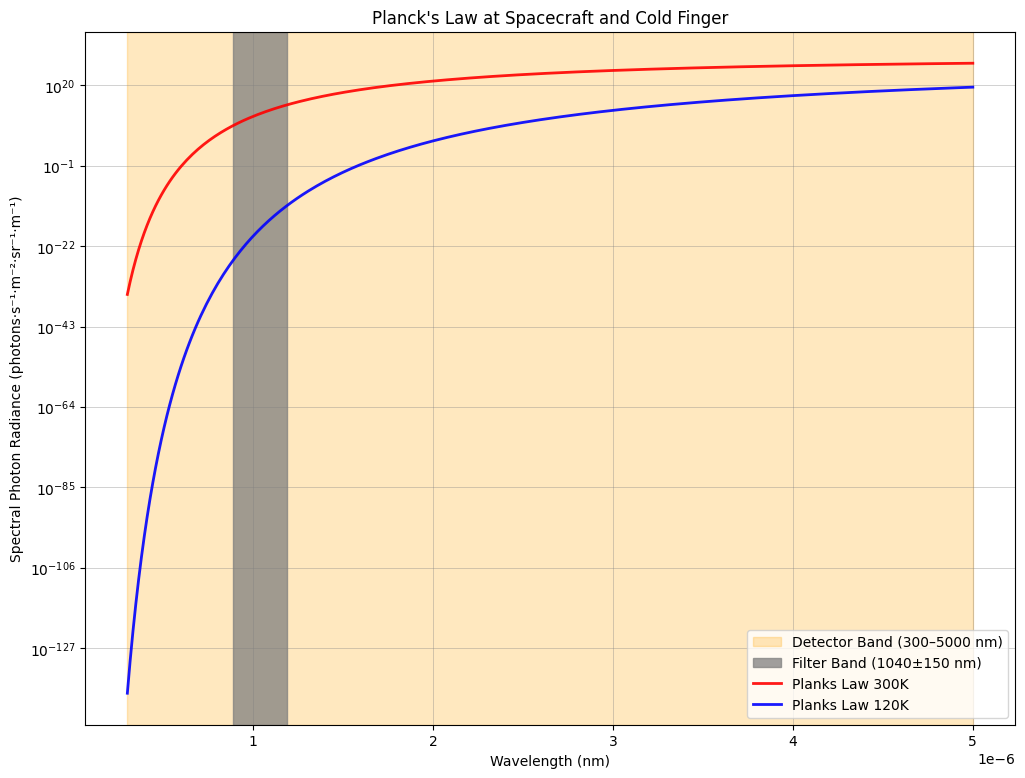

Integrated brightness:
  Cold filter passband   : 2.86e+07 photons·s⁻¹·m⁻²
  Cold filter stopband   : 4.18e+19 photons·s⁻¹·m⁻²
  Hot blackbody photons  : 4.18e+19 photons·s⁻¹·m⁻²
  Cold blackbody photons : 8.28e+12 photons·s⁻¹·m⁻²

Thermal photon rate per pixel:
  Hot passband   : 5.307e-02 photons·s⁻¹
  Hot stopband   : 1.075e+05 photons·s⁻¹
  Cold background: 1.065e+05 photons·s⁻¹
  Total          : 2.139e+05 photons·s⁻¹

Noise Equivalent Power of 7.500e-01 fW/√Hz for the Photodetector:
  Dark current   : 8.336e-01 pA
  Electron rate  : 5.204e+06 electrons·s⁻¹

Noise Equivalent Power of 2.000e-01 fW/√Hz for the Photodetector:
  Dark current   : 2.223e-01 pA
  Electron rate  : 1.388e+06 electrons·s⁻¹

Noise Equivalent Power of 6.667e-02 fW/√Hz for the Photodetector with a third reduction in NA:
  Dark current   : 7.410e-02 pA
  Electron rate  : 4.625e+05 electrons·s⁻¹

With better packaging and insulation, the recent Dark current measurement provided < 1e+05 electrons·s⁻¹


In [22]:
import numpy as np
import scipy.constants as sc
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Constants
pi = np.pi
h = 6.626e-34        # Planck constant [J·s]
kB = 1.38e-23        # Boltzmann constant [J/K]
c = 2.998e8          # Speed of light [m/s]
q = 1.602e-19        # Electron charge [C]

# define function for Planck law (photon radiance)
lam = np.linspace(0.3e-6, 5.0e-6, 300)
T0 = 300
Tc = 120

NEP = 0.75e-15      # NEP [W/√Hz]
QE = 0.9            # Quantum efficiency
F = 1.2             # Excess noise factor

lambda_c = 1040e-9    # Detector cold filter center wavelength (m)
Delta_lambda = 300e-9 # Detector cold filter wavelength range (m)

# Plank's Law Shape
def B_lambda(lam, T):
    return (2 * c / lam**4) / (np.exp(h * c / (lam * kB * T)) - 1)

# For hot photons / (s m^2 sr m)
Spectrum = B_lambda(lam, T0)

# For cold photons / (s m^2 sr m)
Spectrum_cold = B_lambda(lam, Tc)

# Plot
plt.figure(figsize=(12, 9))

# Shade bandpass spectrum
plt.axvspan(0.3e-6, 5e-6, color='orange', alpha=0.25, label="Detector Band (300–5000 nm)")
plt.axvspan(lambda_c - Delta_lambda / 2, lambda_c + Delta_lambda / 2, color='grey', alpha=0.75, label="Filter Band (1040±150 nm)")

plt.plot(lam, Spectrum, linestyle='-', linewidth='2', color='red', alpha=0.9, visible=True, label='Planks Law 300K')
plt.plot(lam, Spectrum_cold, linestyle='-', linewidth='2', color='blue', alpha=0.9, visible=True, label='Planks Law 120K')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Photon Radiance (photons·s⁻¹·m⁻²·sr⁻¹·m⁻¹)")
plt.yscale("log")
plt.title("Planck's Law at Spacecraft and Cold Finger")
plt.grid(which='both', linestyle='-', linewidth='0.5', color='grey', alpha=0.5, visible=True)
plt.legend(loc='lower right')
plt.grid(all)
plt.show()

# Inputs 
eta_pass = 0.85 * 0.85  # Transmittance of cold filter within passband (two cold filters)
eta_block = 1e-6        # Transmittance of cold filter outside passband

emissivity_hot = 1.0
emissivity_cold = 1.0

lambda_det_min = 0.3e-6   # Detector responsivity min wavelength
lambda_det_max = 5.0e-6   # Detector responsivity max wavelength

Wd = 64e-6           # Detector Pixel diameter [m]
# Ad = pi * (Wd/2)**2  # Detector Pixel area [m^2]
Ad =  Wd**2          # Detector Pixel area assuming a square [m^2]

# Field of view
theta_FOV = np.arcsin(0.447) # Half angle of hot filed of view of a detector pixel from hot surrounding at T0

# Filter limits
lambda_filter_min = lambda_c - Delta_lambda / 2
lambda_filter_max = lambda_c + Delta_lambda / 2

# Spectral integrals
L_pass, _ = quad(B_lambda, lambda_filter_min, lambda_filter_max, args=(T0,))
L_hot, _ = quad(B_lambda, lambda_det_min, lambda_det_max, args=(T0,))
L_block = L_hot - L_pass
L_cold, _ = quad(B_lambda, lambda_det_min, lambda_det_max, args=(Tc,))

# Angular factor
angular_hot = pi * np.sin(theta_FOV)**2
angular_cold = pi  # hemisphere

# Photon rates
R_pass = emissivity_hot * eta_pass * L_pass * Ad * angular_hot
R_block = emissivity_hot * eta_block * L_block * Ad * angular_hot
R_cold = emissivity_cold * L_cold * Ad * angular_cold
R_total = R_pass + R_block + R_cold

# Photon energy
hf = h * c / lambda_c

# Dark current from NEP
I_dark = ( (NEP * QE * q / hf)**2 ) / (2 * q * F)

# Electron rate
electron_rate = I_dark / q

# Output
print("Integrated brightness:")
print(f"  Cold filter passband   : {L_pass:.2e} photons·s⁻¹·m⁻²")
print(f"  Cold filter stopband   : {L_block:.2e} photons·s⁻¹·m⁻²")
print(f"  Hot blackbody photons  : {L_hot:.2e} photons·s⁻¹·m⁻²")
print(f"  Cold blackbody photons : {L_cold:.2e} photons·s⁻¹·m⁻²")

print() 

print( "Thermal photon rate per pixel:")
print(f"  Hot passband   : {R_pass:.3e} photons·s⁻¹")
print(f"  Hot stopband   : {R_block:.3e} photons·s⁻¹")
print(f"  Cold background: {R_cold:.3e} photons·s⁻¹")
print(f"  Total          : {R_total:.3e} photons·s⁻¹")

print()

print(f"Noise Equivalent Power of {NEP/1e-15:.3e} fW/√Hz for the Photodetector:")
print(f"  Dark current   : {I_dark/1e-12:.3e} pA")
print(f"  Electron rate  : {electron_rate:.3e} electrons·s⁻¹")

print()

print(f"Noise Equivalent Power of {NEP*0.2/0.75/1e-15:.3e} fW/√Hz for the Photodetector:")
print(f"  Dark current   : {I_dark*0.2/0.75/1e-12:.3e} pA")
print(f"  Electron rate  : {electron_rate*0.2/0.75:.3e} electrons·s⁻¹")

print()

print(f"Noise Equivalent Power of {NEP*0.2/0.75/3/1e-15:.3e} fW/√Hz for the Photodetector with a third reduction in NA:")
print(f"  Dark current   : {I_dark*0.2/0.75/3/1e-12:.3e} pA")
print(f"  Electron rate  : {electron_rate*0.2/0.75/3:.3e} electrons·s⁻¹")

print()

print (f"With better packaging and insulation, the recent Dark current measurement provided < 1e+05 electrons·s⁻¹")
